In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics

# discontinued import tensorflow_addons as tfa
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import load_model


In [4]:
data_dir = '../input/labeled-optical-coherence-tomography-oct/Dataset - train+val+test'
data = tf.keras.preprocessing.image_dataset_from_directory(data_dir)

Found 109309 files belonging to 3 classes.


In [5]:
base_dir = os.path.join("../input/labeled-optical-coherence-tomography-oct/Dataset - train+val+test/")
print('Base directory --> ', os.listdir(base_dir))

Base directory -->  ['val', 'test', 'train']


In [6]:
# NOT EXCHANGED

train_dir = os.path.join(base_dir + "train/")
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = os.path.join(base_dir + "val/")
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = os.path.join(base_dir + "test/")
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']
Validation Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']
Test Directory -->  ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [7]:
from tensorflow.keras.applications import InceptionV3
inc = InceptionV3(input_shape=(224,224,3),weights='imagenet',include_top=False)
for i in inc.layers:
    i.trainable = False
print(inc.summary())

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 111, 111, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 111, 111, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 111, 111, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 109, 109, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 109, 109, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 109, 109, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 109, 109, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 109, 109, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 109, 109, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 54, 54, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 54, 54, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 54, 54, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 54, 54, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 52, 52, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 52, 52, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_4 (Activat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [8]:
model = tf.keras.models.Sequential([
    inc,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation = 'softmax')
])

In [9]:
metrics = ['accuracy',
                tf.keras.metrics.AUC(),
               # tfa.metrics.CohenKappa(num_classes = 4),
               # tfa.metrics.F1Score(num_classes = 4),
                tf.keras.metrics.Precision(), 
                tf.keras.metrics.Recall()]
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = metrics)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)            │ (None, 5, 5, 2048)          │      21,802,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │         204,804 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,007,588 (83.95 MB)

 Trainable params: 204,804 (800.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [10]:
train_datagen = ImageDataGenerator(rescale = 1./255)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size = (224,224), class_mode = 'categorical', 
    batch_size = 500)

Found 76515 images belonging to 4 classes.


In [11]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size = (224,224), class_mode = 'categorical', shuffle=False, 
    batch_size = 50)

Found 10933 images belonging to 4 classes.


In [12]:
validation_datagen = ImageDataGenerator(rescale = 1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size = (224,224), class_mode = 'categorical', 
    batch_size = 16)

Found 21861 images belonging to 4 classes.


In [13]:
# history = model.fit(
#     train_generator,
#     steps_per_epoch = (76515//500),
#     epochs = 30,
#     validation_data = validation_generator,
#     validation_steps = (10933//16),
#     #max_queue_size=100,
#     #workers = 4 ,
#     #verbose = 1
#     )

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


153/153 ━━━━━━━━━━━━━━━━━━━━ 836s 5s/step - accuracy: 0.7122 - auc: 0.8597 - loss: 4.5962 - precision: 0.7168 - recall: 0.7086 - val_accuracy: 0.8785 - val_auc: 0.9782 - val_loss: 0.3489 - val_precision: 0.8900 - val_recall: 0.8694
Epoch 2/30
  1/153 ━━━━━━━━━━━━━━━━━━━━ 2:39 1s/step - accuracy: 0.8820 - auc: 0.9697 - loss: 0.4075 - precision: 0.8875 - recall: 0.8680

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


153/153 ━━━━━━━━━━━━━━━━━━━━ 66s 430ms/step - accuracy: 0.8820 - auc: 0.9697 - loss: 0.4075 - precision: 0.8875 - recall: 0.8680 - val_accuracy: 0.8823 - val_auc: 0.9792 - val_loss: 0.3359 - val_precision: 0.8945 - val_recall: 0.8738
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9032 - auc: 0.9840 - loss: 0.2864 - precision: 0.9143 - recall: 0.8930 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0383 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - accuracy: 0.9120 - auc: 0.9875 - loss: 0.2649 - precision: 0.9192 - recall: 0.9100 - val_accuracy: 0.9022 - val_auc: 0.9844 - val_loss: 0.2828 - val_precision: 0.9114 - val_recall: 0.8929
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9058 - auc: 0.9848 - loss: 0.2800 - precision: 0.9147 - recall: 0.8994 - val_accuracy: 0.9066 - val_auc: 0.9849 - val_loss: 0.2772 - val_precision: 0.9148 - val_recall: 0.8992
Epoch 6/30
153/153 ━━━━━━━━━━━━━━━━

In [37]:
model.save('/kaggle/working/RS_model.h5')

In [38]:
model = load_model('/kaggle/working/RS_model.h5')

In [39]:
import json
history_dict = history.history
with open('history.json', 'w') as f:
    json.dump(history_dict, f)

In [40]:
import json
with open('history.json', 'r') as f:
    history_dict = json.load(f)

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(len(acc))

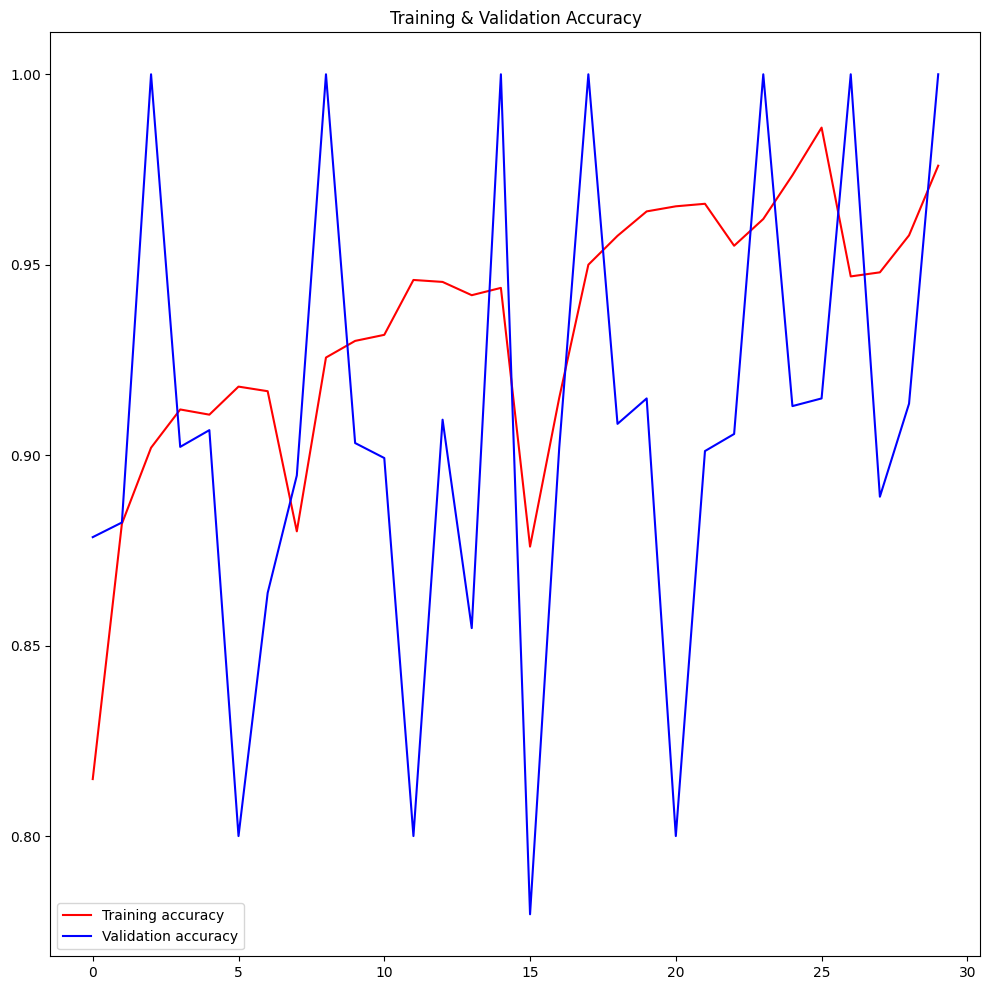

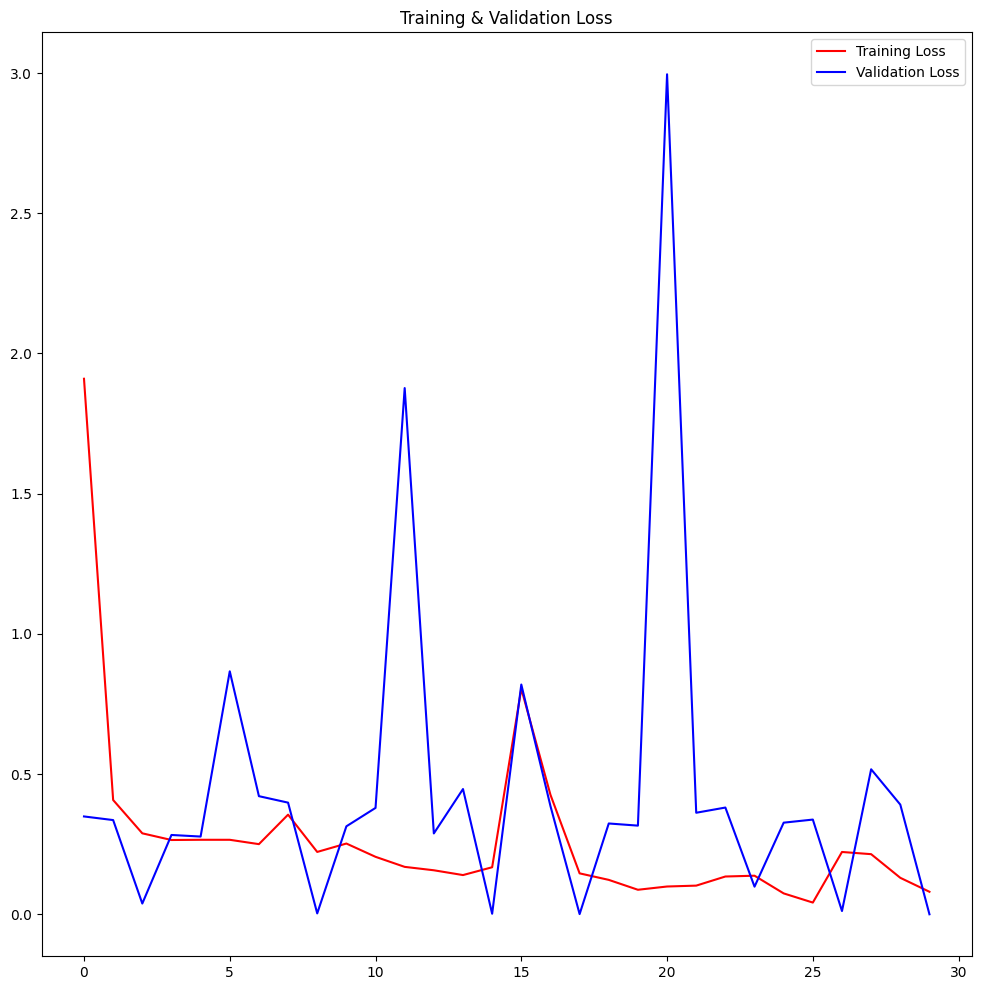

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.figure(figsize=(12,12))
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()

# Evaluating Test Data

In [21]:
model.evaluate(test_generator)

219/219 ━━━━━━━━━━━━━━━━━━━━ 115s 461ms/step - accuracy: 0.9168 - auc: 0.9772 - loss: 0.4010 - precision: 0.9184 - recall: 0.9150


[0.4376843273639679,
 0.9125583171844482,
 0.975272536277771,
 0.9141886830329895,
 0.9110948443412781]

# Classification Report

In [22]:
test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)

predictions = model.predict(test_generator, steps = test_steps_per_epoch)

predicted_classes = np.argmax(predictions, axis=1)

<ipython-input-22-67ac5c6a3380>:1: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  test_steps_per_epoch = np.math.ceil(test_generator.samples / test_generator.batch_size)


219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 181ms/step


In [24]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [25]:
report = sklearn.metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report) 

              precision    recall  f1-score   support

         CNV       0.91      0.95      0.93      3746
         DME       0.86      0.81      0.83      1161
      DRUSEN       0.82      0.46      0.59       887
      NORMAL       0.93      0.98      0.96      5139

    accuracy                           0.91     10933
   macro avg       0.88      0.80      0.83     10933
weighted avg       0.91      0.91      0.91     10933



# Confusion Matrix

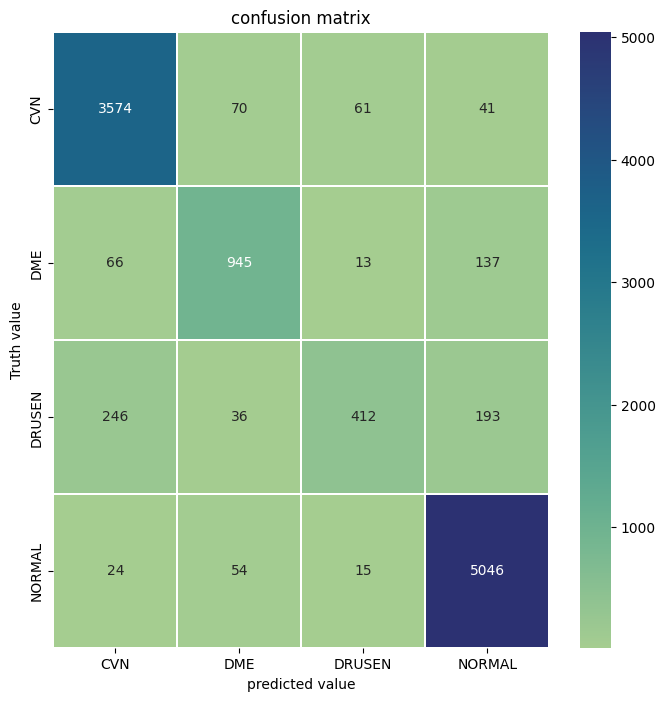

[[3574   70   61   41]
 [  66  945   13  137]
 [ 246   36  412  193]
 [  24   54   15 5046]]


In [26]:
X_Label = ['CVN','DME','DRUSEN','NORMAL']
Y_Label = ['CVN','DME','DRUSEN','NORMAL']

cm = sklearn.metrics.confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,8))
sns.heatmap(cm, fmt='.0f', cmap="crest", annot=True, linewidths=0.2, xticklabels=X_Label, yticklabels=Y_Label)
plt.title('confusion matrix')
plt.xlabel('predicted value')
plt.ylabel('Truth value')
plt.show()
print(sklearn.metrics.confusion_matrix(true_classes, predicted_classes))

# ROC

In [29]:
import scikitplot as skplt
import scipy
!pip install --upgrade scikitplot

y_true = true_classes
y_probas = predictions
skplt.metrics.plot_roc_curve(y_true, y_probas)
plt.show()

ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.10/dist-packages/scipy/__init__.py)

# Print Accuracy

In [ ]:
print("Accuracy", sklearn.metrics.accuracy_score(true_classes, predicted_classes))